<a href="https://colab.research.google.com/github/11249A018-jithendra/R-program/blob/main/11249A018.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "AQI Dataset Loaded Successfully"
  StationID              Date                City                AQI       
 Length:10          Min.   :2024-01-15   Length:10          Min.   : 38.0  
 Class :character   1st Qu.:2024-01-17   Class :character   1st Qu.: 66.0  
 Mode  :character   Median :2024-01-19   Mode  :character   Median : 99.5  
                    Mean   :2024-01-19                      Mean   :124.4  
                    3rd Qu.:2024-01-21                      3rd Qu.:159.2  
                    Max.   :2024-01-24                      Max.   :295.0  
 Pollutant_Conc  Primary_Pollutant    Category        
 Min.   :10.00   Length:10          Length:10         
 1st Qu.:22.75   Class :character   Class :character  
 Median :32.50   Mode  :character   Mode  :character  
 Mean   :37.70                                        
 3rd Qu.:48.75                                        
 Max.   :80.00                                        


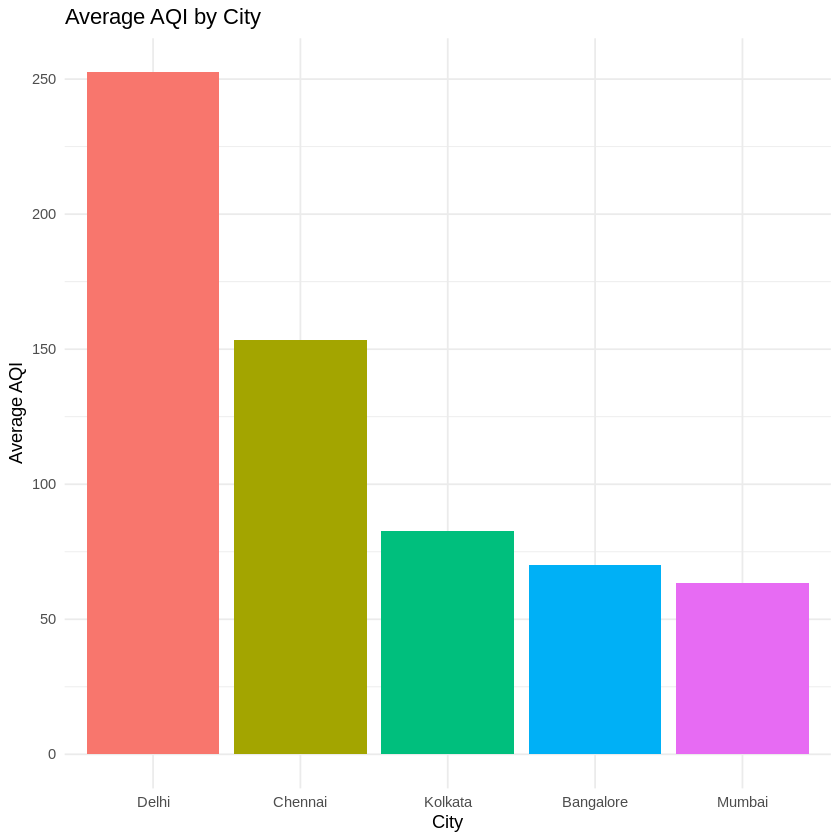

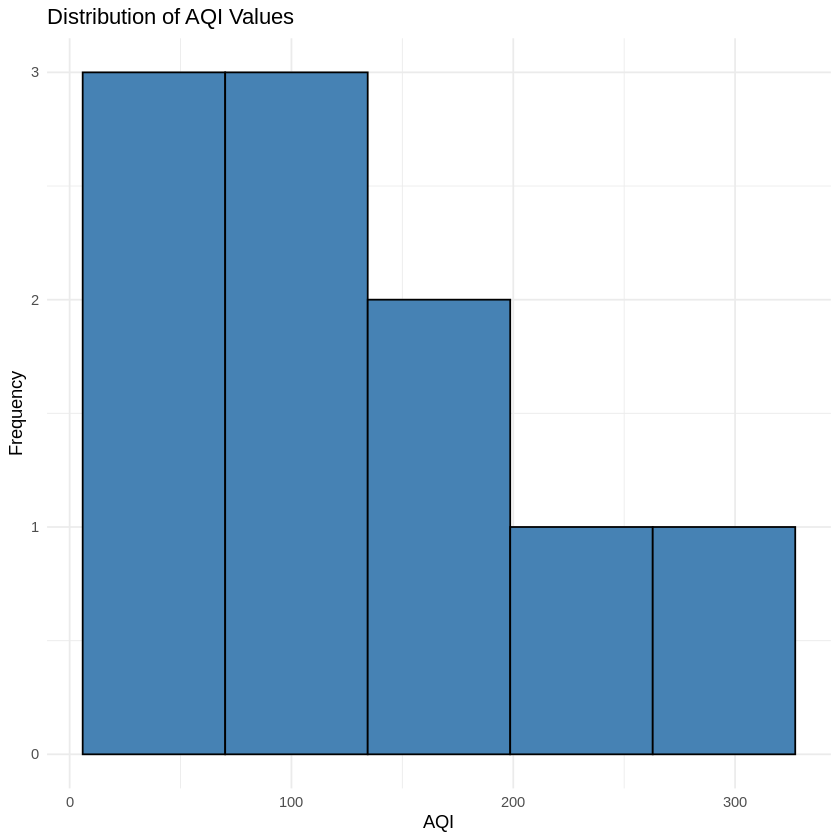

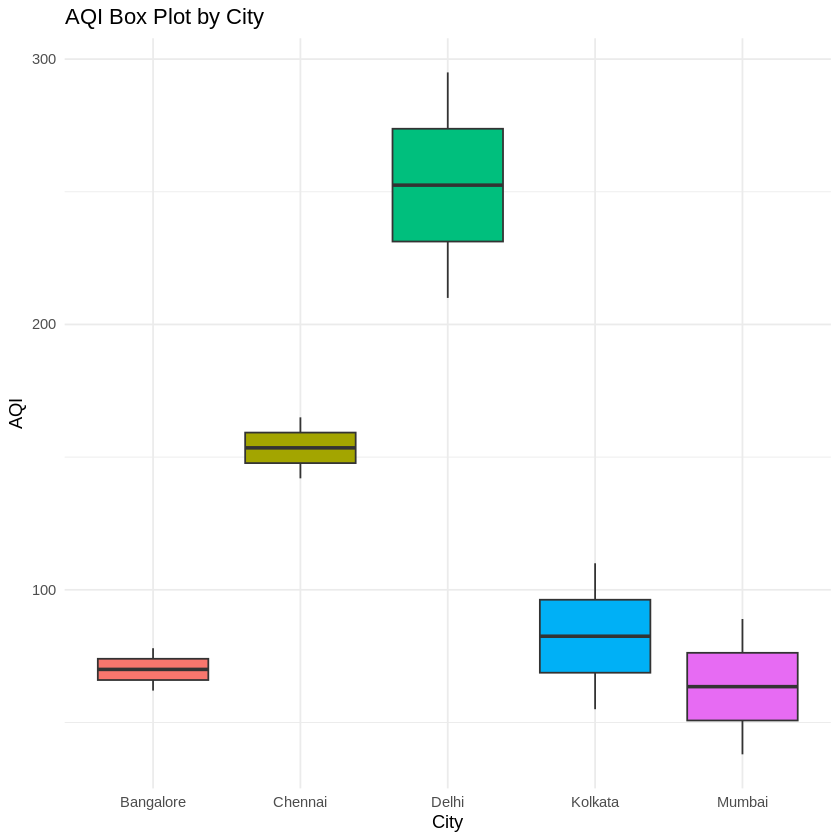

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


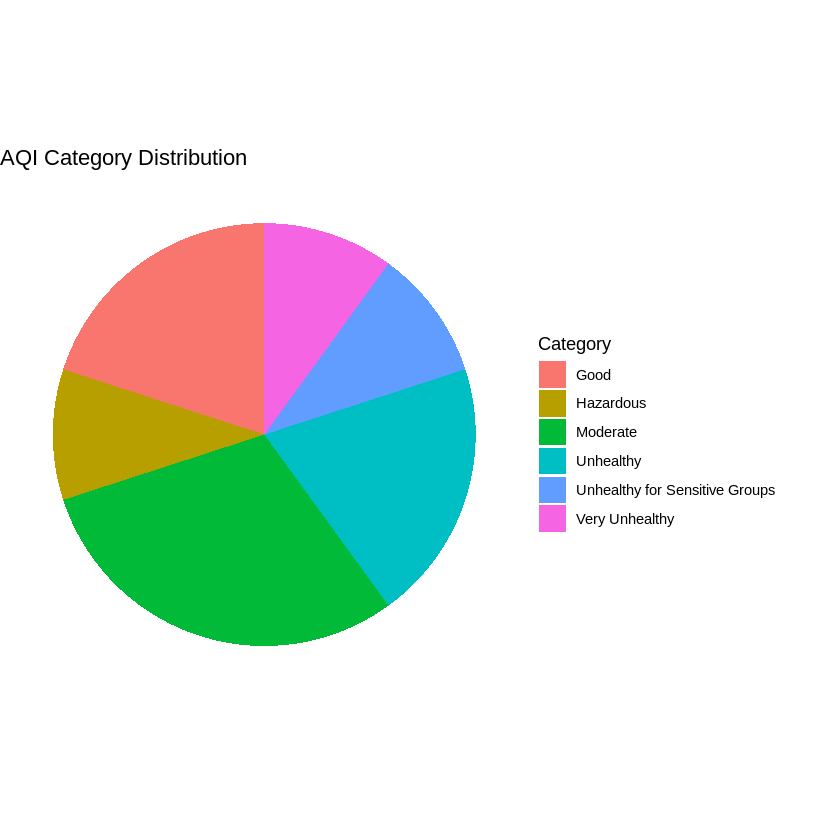

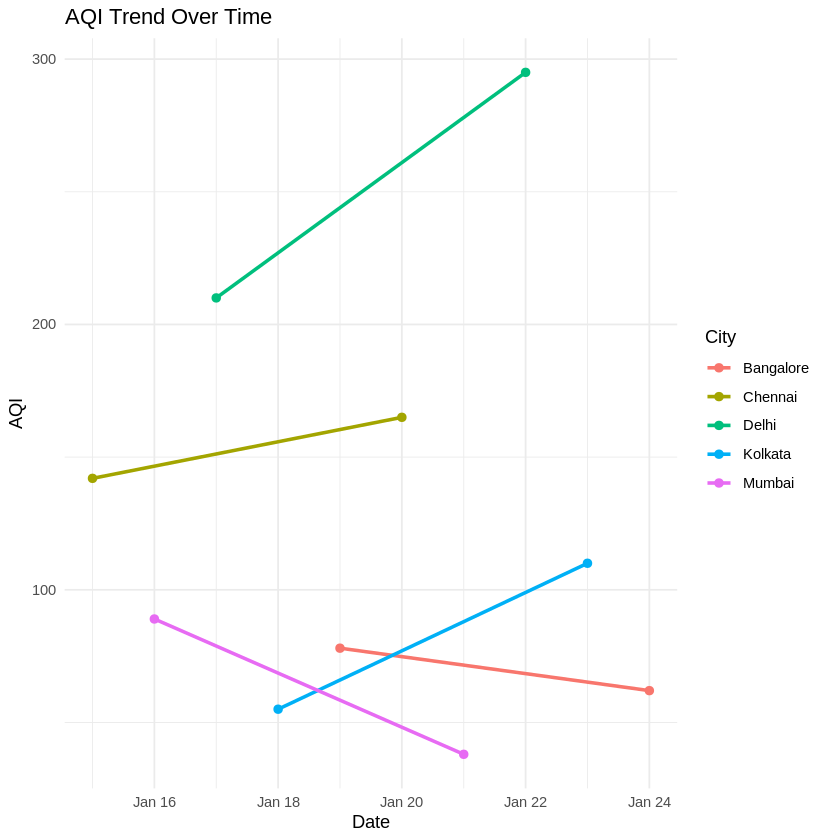

In [1]:
# ============================================
# Experiment 3: Air Quality Index Monitoring
# ============================================

# Step 1: Load required libraries
library(ggplot2)
library(dplyr)

# Step 2: Define the AQI dataset
aqi_data <- data.frame(
  StationID = c("S001","S002","S003","S004","S005",
                "S006","S007","S008","S009","S010"),
  Date = as.Date(c("2024-01-15","2024-01-16","2024-01-17",
                   "2024-01-18","2024-01-19","2024-01-20",
                   "2024-01-21","2024-01-22","2024-01-23",
                   "2024-01-24")),
  City = c("Chennai","Mumbai","Delhi","Kolkata","Bangalore",
           "Chennai","Mumbai","Delhi","Kolkata","Bangalore"),
  AQI = c(142, 89, 210, 55, 78, 165, 38, 295, 110, 62),
  Pollutant_Conc = c(45, 30, 60, 20, 25, 50, 10, 80, 35, 22),
  Primary_Pollutant = c("PM2.5","PM10","PM2.5","CO","NO2",
                        "PM2.5","SO2","PM2.5","PM10","O3"),
  Category = c("Unhealthy","Moderate","Very Unhealthy","Good",
               "Moderate","Unhealthy","Good","Hazardous",
               "Unhealthy for Sensitive Groups","Moderate")
)

# Step 3: View dataset
print("AQI Dataset Loaded Successfully")
print(summary(aqi_data))

# Step 4: Average AQI by City (sorted)
avg_aqi <- aqi_data %>%
  group_by(City) %>%
  summarise(Avg_AQI = mean(AQI)) %>%
  arrange(desc(Avg_AQI))

# Reorder factor levels
avg_aqi$City <- factor(avg_aqi$City, levels = avg_aqi$City)

# Bar Chart
ggplot(avg_aqi, aes(x = City, y = Avg_AQI, fill = City)) +
  geom_bar(stat = "identity") +
  labs(title = "Average AQI by City",
       x = "City", y = "Average AQI") +
  theme_minimal() +
  theme(legend.position = "none")

# Step 5: Histogram – AQI Distribution
ggplot(aqi_data, aes(x = AQI)) +
  geom_histogram(fill = "steelblue", color = "black", bins = 5) +
  labs(title = "Distribution of AQI Values",
       x = "AQI", y = "Frequency") +
  theme_minimal()

# Step 6: Box Plot – AQI by City
ggplot(aqi_data, aes(x = City, y = AQI, fill = City)) +
  geom_boxplot() +
  labs(title = "AQI Box Plot by City",
       x = "City", y = "AQI") +
  theme_minimal() +
  theme(legend.position = "none")

# Step 7: Pie Chart (Improved using ggplot)
category_counts <- table(aqi_data$Category)
category_df <- as.data.frame(category_counts)
colnames(category_df) <- c("Category", "Count")

ggplot(category_df, aes(x = "", y = Count, fill = Category)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y") +
  labs(title = "AQI Category Distribution") +
  theme_void()

# Step 8: AQI Trend Over Time
ggplot(aqi_data, aes(x = Date, y = AQI, color = City, group = City)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  labs(title = "AQI Trend Over Time",
       x = "Date", y = "AQI") +
  theme_minimal()